# Sales Performance & Customer Insights Analysis

## Aim

The aim of this project is to analyze sales data to identify key trends, patterns, and factors affecting business performance, and to provide actionable insights for improving profitability and decision-making.

## Objectives

- Analyze overall sales performance across time. 
- Identify top-performing products and categories.  
- Evaluate regional and customer segment performance.  
- Understand the relationship between sales, profit, and discount.  
- Provide data-driven recommendations to improve business outcomes.  

## Business Problem

Businesses often struggle to understand which products, regions, and customer segments contribute most to revenue and profitability. Additionally, excessive discounting and poor pricing strategies can lead to financial losses.

This project aims to address these challenges by analyzing sales data to uncover inefficiencies and identify opportunities for growth and optimization.

## Approach

- Data cleaning and preprocessing to ensure data quality.  
- Exploratory Data Analysis (EDA) to identify patterns and trends.  
- Visualization of key metrics such as sales, profit, and discount.  
- Correlation analysis to understand relationships between variables.  
- Interpretation of results to generate business insights and recommendations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Superstore_dataset.csv", encoding='latin1')

In [3]:
df.describe()
df.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

# Convert dates

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

### Date Conversion

The `Order Date` and `Ship Date` columns were converted into datetime format to enable time-based analysis such as sales trends and delivery performance.

# Check duplicates

In [5]:
df.duplicated().sum()

np.int64(1)

### Duplicate Check

The dataset was checked for duplicate records to ensure data integrity.

- The output showed `np.int64(1)`, indicating that there was 1 duplicate row present in the dataset.

In [6]:
df = df.drop_duplicates()

### Removing Duplicates

The duplicate record was removed using the `drop_duplicates()` function to ensure that each entry in the dataset is unique and does not bias the analysis.

In [7]:
df.duplicated().sum()

np.int64(0)

### Verification

After removing duplicates, the dataset was checked again:

- The output `np.int64(0)` confirms that there are no duplicate records remaining.

This ensures that the dataset is clean and ready for further analysis.

## Sales Trend Analysis

This analysis examines how sales vary over time to identify trends and patterns in business performance.

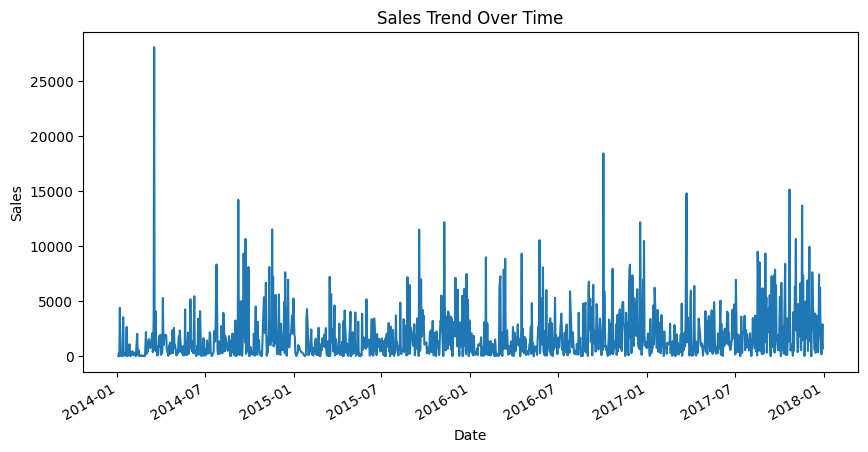

In [8]:
sales_trend = df.groupby('Order Date')['Sales'].sum()

plt.figure(figsize=(10,5))
sales_trend.plot()
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

### Insight

- Sales show fluctuations over time with occasional spikes.  
- This indicates seasonal demand and irregular high-value transactions.  

## Category-wise Sales Analysis

This section identifies which product categories contribute the most to total sales.

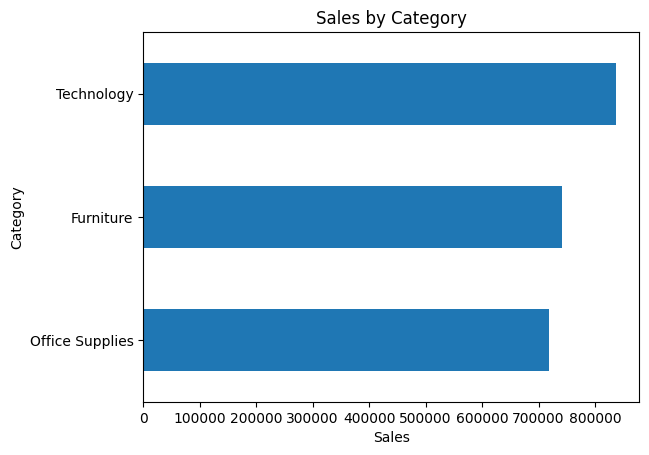

In [9]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values()

category_sales.plot(kind='barh')
plt.title("Sales by Category")
plt.xlabel("Sales")
plt.show()

### Insight

- Technology category generates the highest sales. 
- Furniture and Office Supplies contribute slightly lower but still significant revenue.

## Profit Analysis by Category

Analyzing which categories contribute most to overall profitability.

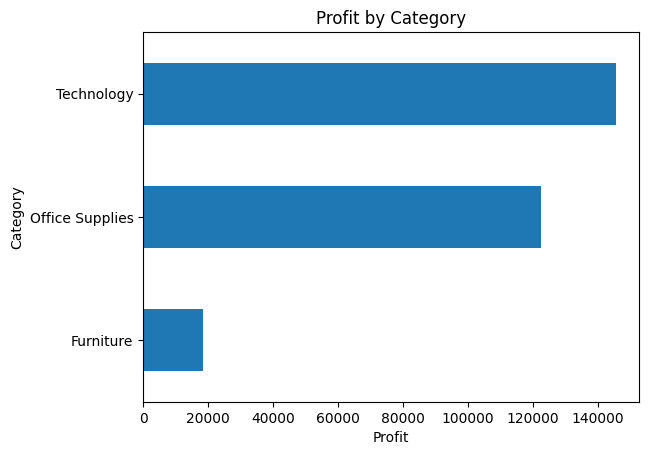

In [10]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values()

category_profit.plot(kind='barh')
plt.title("Profit by Category")
plt.xlabel("Profit")
plt.show()

### Insight

- Technology generates the highest profit.  
- Office Supplies also contribute strongly.  
- Furniture shows relatively low profit despite decent sales. 

## Top Products Analysis

Identifying the top-performing products based on total sales.

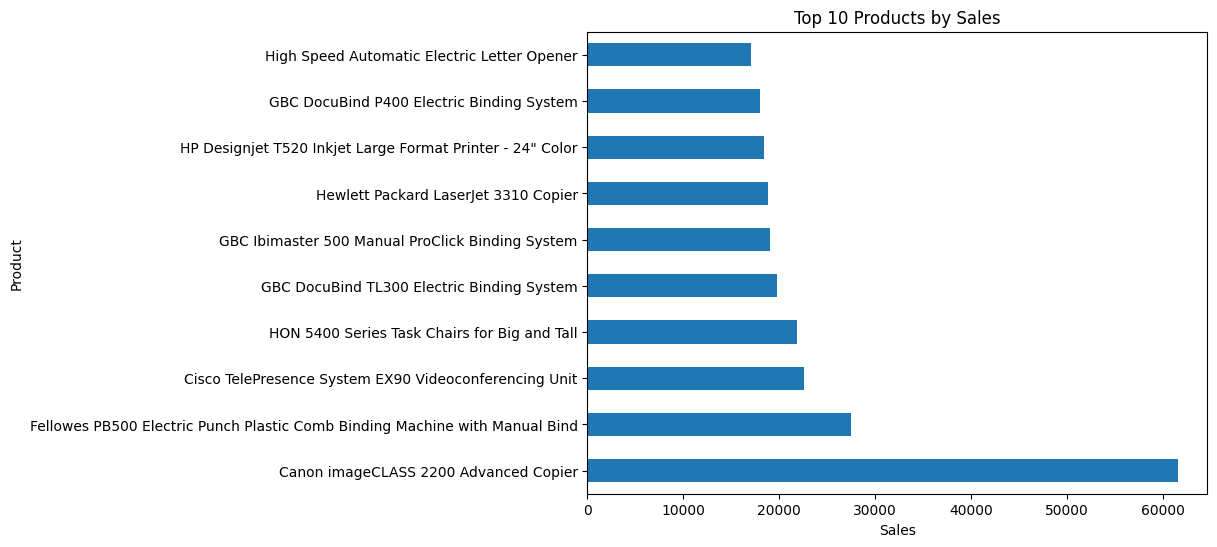

In [11]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh', figsize=(8,6))
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

### Insight

- A few products dominate overall sales.  
- Canon imageCLASS 2200 Advanced Copier is the highest-selling product-  
- Sales are concentrated among a small number of items.

## Regional Sales Analysis

Evaluating sales performance across different geographical regions.

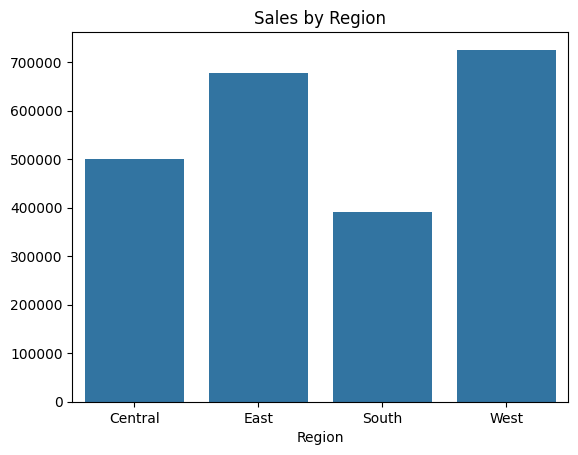

In [12]:
region_sales = df.groupby('Region')['Sales'].sum()

sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Sales by Region")
plt.show()

### Insight

- West region generates the highest sales.  
- South region shows the lowest performance.  
- Regional differences highlight potential growth opportunities.

## Sales vs Profit Analysis

The scatter plot illustrates the relationship between sales and profit.

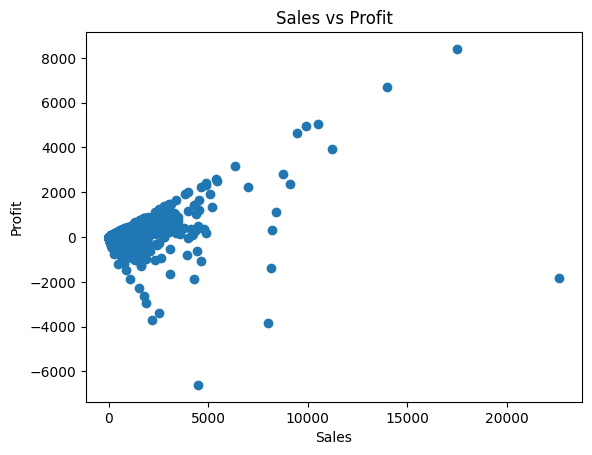

In [13]:
plt.scatter(df['Sales'], df['Profit'])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

### Insight

- Most transactions generate low to moderate sales with corresponding profit.
- Some high-sales transactions result in negative profit, indicating losses.
- This suggests that high sales do not always guarantee profitability.
- A few transactions generate very high profit, representing top-performing cases.

This highlights the importance of controlling discounts and operational costs to ensure sustainable profitability.

## Customer Segment Analysis

Understanding how different customer segments contribute to total sales.

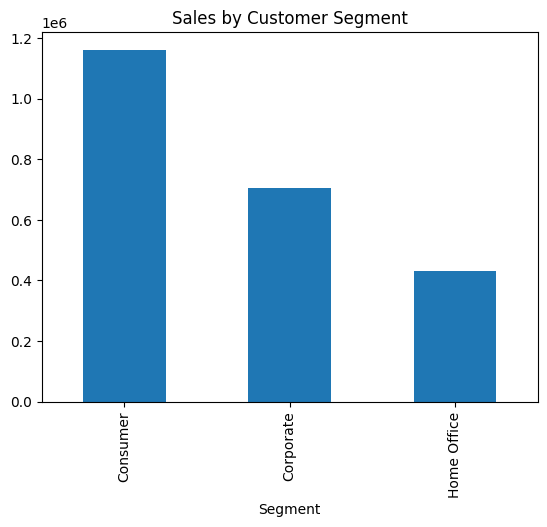

In [14]:
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales.plot(kind='bar')
plt.title("Sales by Customer Segment")
plt.show()

### Insight

- Consumer segment contributes the most to sales.  
- Corporate segment follows.  
- Home Office contributes the least.

## Discount vs Profit Analysis

This analysis evaluates how discounting impacts profitability.

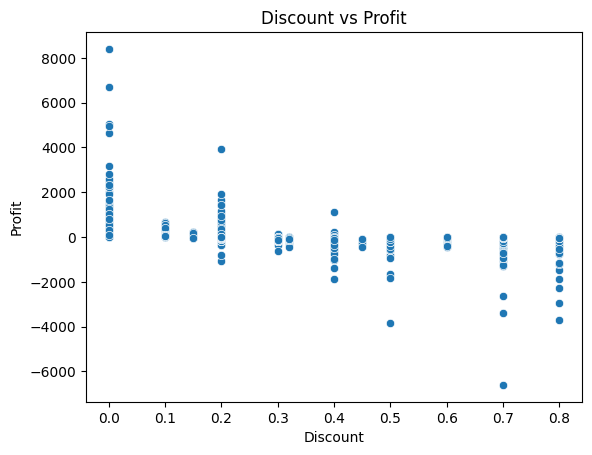

In [15]:
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")
plt.show()

### Insight

- Higher discounts are associated with lower or negative profits.  
- Excessive discounting significantly reduces profitability. 

## Correlation Analysis

The correlation matrix shows relationships between key numerical variables.

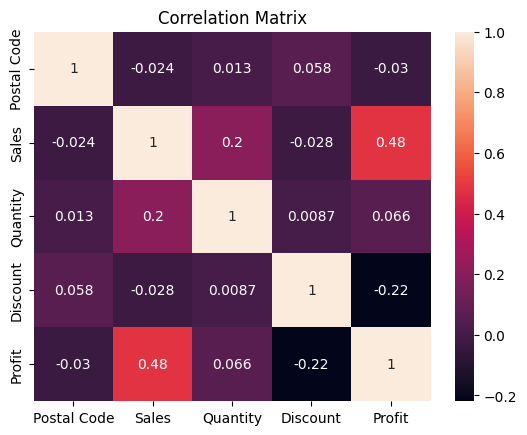

In [16]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

### Insight

- Sales and Profit have a moderate positive correlation (0.48), indicating that higher sales generally lead to higher profit.
- Discount has a negative correlation with Profit (-0.22), suggesting that higher discounts reduce profitability.
- Quantity has a weak positive relationship with Sales, indicating limited influence on revenue.
- Postal Code does not provide meaningful insights and can be ignored for analysis.

Overall, discount strategy plays a crucial role in affecting business profitability.

## Analyis Key Insights

- Sales and profit show a positive relationship, but high sales do not always result in high profit.  
- Discounting negatively impacts profitability, with higher discounts leading to lower profit.  
- Certain products generate high revenue but contribute little or negative profit.  
- Customer segments and regions differ significantly in performance.  
- A few high-performing transactions contribute significantly to overall profit. 

## Business Recommendations

- Optimize discount strategies to prevent loss-making sales.  
- Focus on high-profit products and reduce emphasis on low-margin items.  
- Target high-performing regions and customer segments for expansion.  
- Review pricing strategies for products with high sales but low profit.  
- Implement data-driven decision-making for better financial performance.  

## Conclusion

This analysis provides a comprehensive understanding of sales performance and profitability drivers. While sales contribute to revenue growth, factors such as discounting and cost management significantly influence profitability.

The insights derived from this project can help businesses make informed decisions, improve operational efficiency, and enhance overall financial performance.